In [1]:
!pip install "groundingdino-py" "segment-anything-py"
!mkdir -p /kaggle/working/groundingdino
!wget -q https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/main/groundingdino/config/GroundingDINO_SwinT_OGC.py -O /kaggle/working/groundingdino/GroundingDINO_SwinT_OGC.py

!wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth -O /kaggle/working/groundingdino/groundingdino_swint_ogc.pth


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - \ done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.0/455.0 kB 12.6 MB/s eta 0:00:00
  Created wheel for groundingdino-py: filename=groundingdino_py-0.4.0-py2.py3-none-any.whl size=88735 sha256=e7e1757c2a08befb4d9c850975192b055f2b1b6b6d773ca9b94cfd8763fc083c
  Stored in directory: /root/.cache/pip/wheels/72/25/30/97b491abad279d329c62bef1e91bc56bf2fd40b22281068e1d
Successfully built groundingdino-py


In [2]:
!wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth \
       -O /kaggle/working/groundingdino_swint_ogc.pth

In [3]:
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -O /kaggle/working/sam_vit_h_4b8939.pth

In [4]:
import os
import gc
import cv2
import torch
import numpy as np
import pandas as pd
import groundingdino
from tqdm import tqdm
import supervision as sv
from typing import Optional
import matplotlib.pyplot as plt
from torch import inference_mode
from groundingdino.util.inference import load_model, load_image, predict, annotate
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor


In [5]:
def create_dataframe(dataset_path, class_list):
    """Crea un DataFrame con rutas de imágenes, etiquetas y prompts a partir de una lista de clases."""
    data = []

    for cls in class_list:
        class_folder = os.path.join(dataset_path, cls)
        prompt = cls.split('.', 1)[1] if '.' in cls else cls

        for img_file in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_file)
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                data.append({
                    "image_path": img_path,
                    "label": cls,
                    "prompt": prompt
                })
    df = pd.DataFrame(data)
    return df

dataset_path = "/kaggle/input/caltech-256/256_ObjectCategories"
classes = ["001.ak47", "005.baseball-glove", "003.backpack"]

df = create_dataframe(dataset_path, classes)
print(df.head())


                                          image_path     label prompt
0  /kaggle/input/caltech-256/256_ObjectCategories...  001.ak47   ak47
1  /kaggle/input/caltech-256/256_ObjectCategories...  001.ak47   ak47
2  /kaggle/input/caltech-256/256_ObjectCategories...  001.ak47   ak47
3  /kaggle/input/caltech-256/256_ObjectCategories...  001.ak47   ak47
4  /kaggle/input/caltech-256/256_ObjectCategories...  001.ak47   ak47


In [6]:
import torch

torch.cuda.empty_cache()
torch.cuda.synchronize()

In [7]:

class SegmentationModel:
    """Combina GroundingDINO y Segment Anything Model (SAM) para segmentación de imágenes basada en texto.
        Sirve para etiquetar y segmentar objetos en imágenes según prompts de texto."""
    def __init__(
        self,
        sam_checkpoint: str,
        config_path: str,
        weights_path: str,
        sam_model_type:Optional[str] = "vit_h",
        box_thresh: Optional[float] = 0.35,
        text_thresh: Optional[float] = 0.25
    ):
        self.sam_checkpoint = sam_checkpoint
        self.config_path = config_path
        self.weights_path = weights_path
        self.sam_model_type = sam_model_type
        self.box_thresh = box_thresh
        self.text_thresh = text_thresh

        self.detection_model = load_model(config_path, weights_path)
        self.sam = sam_model_registry[sam_model_type](checkpoint=sam_checkpoint)
        self.sam.to(device="cuda")  # or "cpu"
        self.mask_predictor = SamPredictor(self.sam)

    @staticmethod
    def scale_box( box_cxcywh, H, W):
        """ Escala una caja de coordenadas (cx,cy,w,h) a (x0,y0,x1,y1) en píxeles,
            asegurándose de que las coordenadas estén dentro de los límites de la imagen.
        """
        cx, cy, w, h = box_cxcywh
        x0 = cx - w / 2.0
        y0 = cy - h / 2.0
        x1 = cx + w / 2.0
        y1 = cy + h / 2.0
        
        # Limitar coordenadas dentro de los límites de la imagen
        box_xyxy = np.array([
            max(0, min(W - 1, x0)),
            max(0, min(H - 1, y0)),
            max(0, min(W - 1, x1)),
            max(0, min(H - 1, y1)),
        ], dtype=np.int32)
        return box_xyxy
    
    @staticmethod
    def convert_coordinates(h, w, boxes):
        """Convierte cajas normalizadas (valores entre 0 y 1) a coordenadas en píxeles."""
        boxes_pixel = boxes.clone()
        boxes_pixel[:, 0] = boxes[:, 0] * w   # x_min
        boxes_pixel[:, 1] = boxes[:, 1] * h   # y_min
        boxes_pixel[:, 2] = boxes[:, 2] * w   # x_max
        boxes_pixel[:, 3] = boxes[:, 3] * h   # y_max
        
        boxes_np = boxes_pixel.numpy()
        return boxes_np
    
    def detect_objects(self, image_path: str, prompt: str):
        """Detecta objetos en una imagen dada una indicación de texto (prompt)."""
        image_source, image = load_image(image_path)

        boxes, logits, phrases = predict(
            model=self.detection_model,
            image=image,
            caption=prompt,
            box_threshold=self.box_thresh,
            text_threshold=self.text_thresh
        )
        annotated = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=phrases)
        H, W = image_source.shape[:2]
        boxes_np = self.convert_coordinates(H, W, boxes)
        return annotated, boxes_np, H, W

    def get_best_mask(self, box_cxcywh, H, W):
        """Obtiene la mejor máscara para una caja dada utilizando el predictor SAM."""
        box_xyxy = self.scale_box(box_cxcywh, H, W)
        box_xyxy = np.array(box_xyxy, dtype=np.float32)

        masks_i, scores_i, _ = self.mask_predictor.predict(
            box=box_xyxy,
            multimask_output=True
        )
            
        if isinstance(masks_i, torch.Tensor):  masks_i = masks_i.cpu().numpy()
        if isinstance(scores_i, torch.Tensor): scores_i = scores_i.cpu().numpy()

        best = scores_i.argmax(axis=1)[0] if scores_i.ndim == 2 else scores_i.argmax()
        best_mask = masks_i[0, best] if masks_i.ndim == 4 else masks_i[best]

        return best_mask.astype(bool)

    def get_all_masks(self, boxes_np, H, W):
        """Obtiene máscaras para todas las cajas detectadas."""
        all_masks = []
        for i in range(len(boxes_np)):
            box_cxcywh = boxes_np[i]
            best_mask = self.get_best_mask(box_cxcywh, H, W)
            all_masks.append(best_mask)

        if len(all_masks) == 0:
            return None
        masks = np.stack(all_masks, axis=0)
        return masks
    
    def build_detections(self, image_bgr, masks):
        """Construye las detecciones anotadas utilizando las máscaras obtenidas."""
        box_annotator = sv.BoxAnnotator(color=sv.Color.red())
        mask_annotator = sv.MaskAnnotator(color=sv.Color.red())
                
        detections = sv.Detections(
            xyxy=sv.mask_to_xyxy(masks=masks),
            mask=masks
        )
        segmented_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)
        return segmented_image

    
    def segment_image(self, image_path: str, prompt: str):
        """Segmenta una imagen dada una indicación de texto (prompt)."""
        annotated, boxes_np, H, W = self.detect_objects(image_path, prompt)

        image_bgr = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        self.mask_predictor.set_image(image_rgb)
        
        if not boxes_np.size == 0:
            masks = self.get_all_masks(boxes_np, H, W)
            if masks is not None:
                segmented_image = self.build_detections(image_bgr, masks)

                return image_bgr, annotated, segmented_image
        return image_bgr, None, None

    def segment_images(self, df):
        """Segmenta múltiples imágenes según un DataFrame que contiene rutas de imágenes y prompts."""
        results = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing Images"):
            path = row["image_path"]
            prompt = row["prompt"]
            source_image, annotated_image, segmented_image = self.segment_image( path, prompt)
            results.append({
                "path": path,
                "prompt" : prompt,
                "source_image": source_image,
                "annotated_image": annotated_image,
                "segmented_image": segmented_image
            })
        return results
    
    def graph_results(self, df, results, col, value):
        """Grafica los resultados de segmentación para una imagen específica basada en un valor de columna dado."""
        matching_indices = df[df[col] == value].index.tolist()
        assert len(matching_indices) == 1 , f"Expected exactly one match for {col}={value}, but found {len(matching_indices)}."
        index = matching_indices[0]
        result = results[index]
        source_image = result["source_image"]
        annotated_image = result["annotated_image"]
        segmented_image = result["segmented_image"]

        images = [source_image, annotated_image, segmented_image]
        titles = ["Source Image", "Annotated Image", "Segmented Image"]

        sv.plot_images_grid(
            images=images,
            grid_size=(1, 3),
            titles=titles
        )

    def clear_memory(self):
        """Libera la memoria ocupada por los modelos."""
        del self.detection_model
        del self.sam
        del self.mask_predictor
        gc.collect()
        torch.cuda.empty_cache()

In [8]:
sam_checkpoint = "/kaggle/working/sam_vit_h_4b8939.pth"
config_path  = "/kaggle/working/groundingdino/GroundingDINO_SwinT_OGC.py"
weights_path = "/kaggle/working/groundingdino/groundingdino_swint_ogc.pth"
sam_model_type = "vit_h"
box_thresh   = 0.35
text_thresh  = 0.25
segmentation_model = SegmentationModel(
    sam_checkpoint=sam_checkpoint,
    config_path=config_path,
    weights_path=weights_path,
    sam_model_type=sam_model_type,
    box_thresh=box_thresh,
    text_thresh=text_thresh
)

/opt/conda/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /usr/local/src/pytorch/aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [9]:
results = segmentation_model.segment_images(df)

Processing Images:   0%|          | 0/397 [00:00<?, ?it/s]/opt/conda/lib/python3.10/site-packages/transformers/modeling_utils.py:962: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torch/utils/checkpoint.py:429: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torch/utils/checkpoint.py:61: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
2025-11-02 19:43:12.401711: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempt

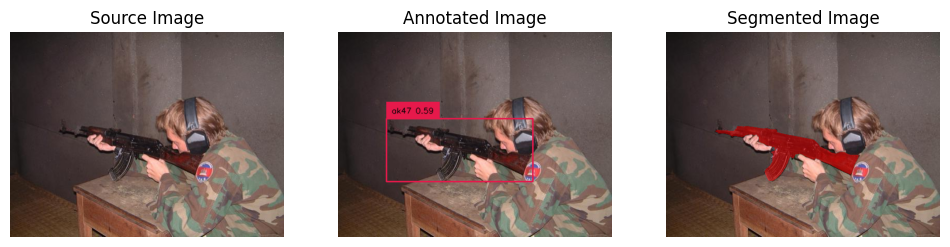

In [10]:
segmentation_model.graph_results(df, results, col="image_path", value="/kaggle/input/caltech-256/256_ObjectCategories/001.ak47/001_0010.jpg")

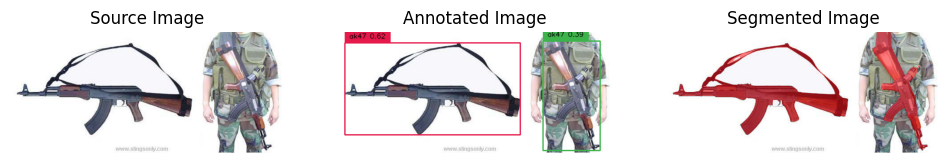

In [11]:
segmentation_model.graph_results(df, results, col="image_path", value="/kaggle/input/caltech-256/256_ObjectCategories/001.ak47/001_0012.jpg")

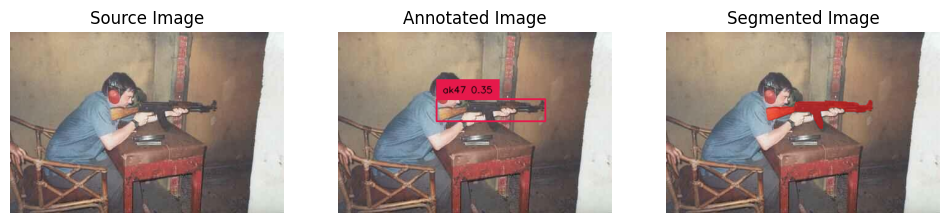

In [12]:
segmentation_model.graph_results(df, results, col="image_path", value="/kaggle/input/caltech-256/256_ObjectCategories/001.ak47/001_0075.jpg")

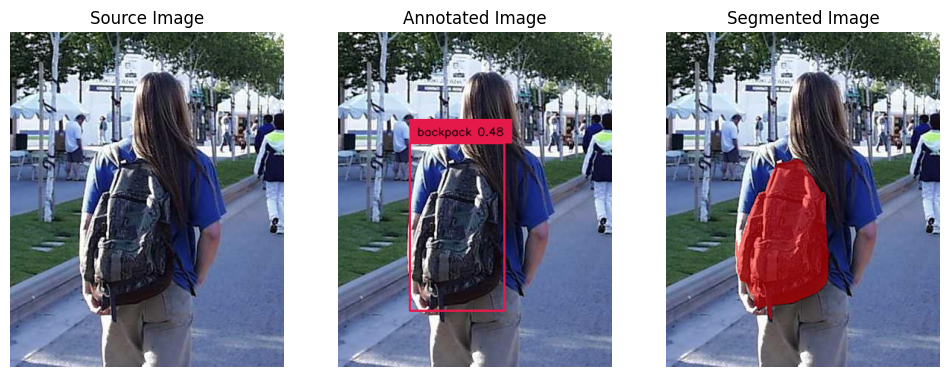

In [13]:
segmentation_model.graph_results(df, results, col="image_path", value="/kaggle/input/caltech-256/256_ObjectCategories/003.backpack/003_0015.jpg")

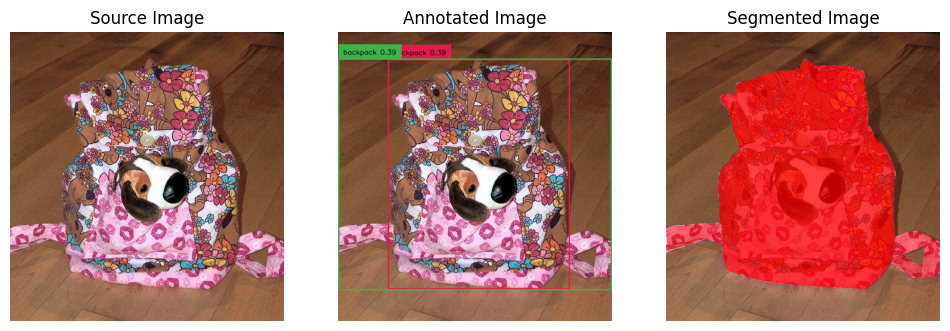

In [14]:
segmentation_model.graph_results(df, results, col="image_path", value="/kaggle/input/caltech-256/256_ObjectCategories/003.backpack/003_0045.jpg")

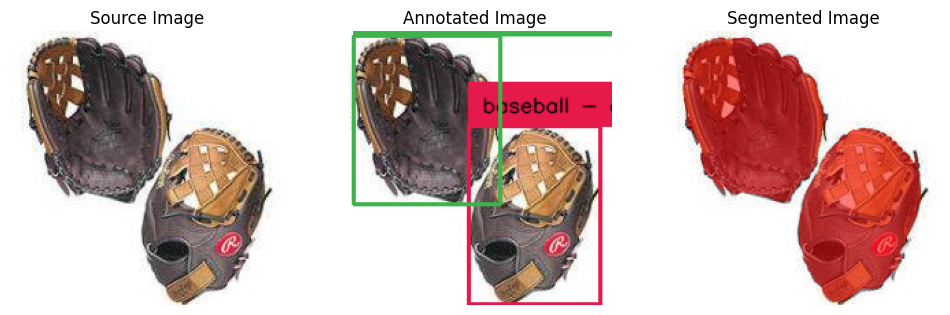

In [15]:
segmentation_model.graph_results(df, results, col="image_path", value="/kaggle/input/caltech-256/256_ObjectCategories/005.baseball-glove/005_0001.jpg")

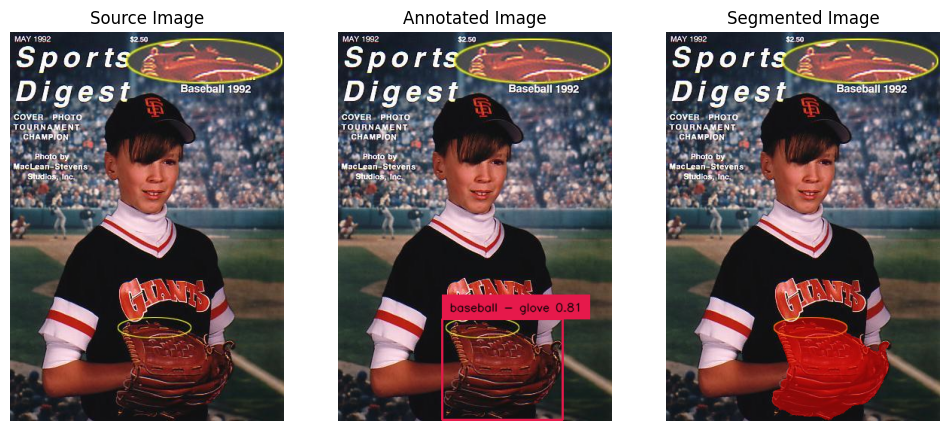

In [16]:
segmentation_model.graph_results(df, results, col="image_path", value="/kaggle/input/caltech-256/256_ObjectCategories/005.baseball-glove/005_0041.jpg")

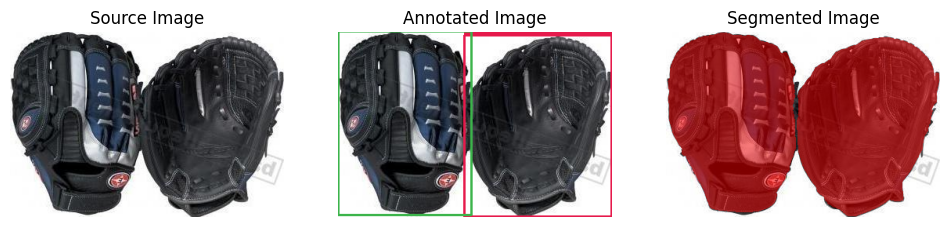

In [17]:
segmentation_model.graph_results(df, results, col="image_path", value="/kaggle/input/caltech-256/256_ObjectCategories/005.baseball-glove/005_0112.jpg")

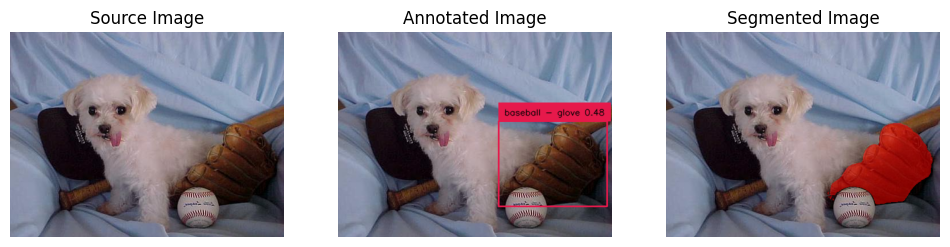

In [18]:
segmentation_model.graph_results(df, results, col="image_path", value="/kaggle/input/caltech-256/256_ObjectCategories/005.baseball-glove/005_0089.jpg")

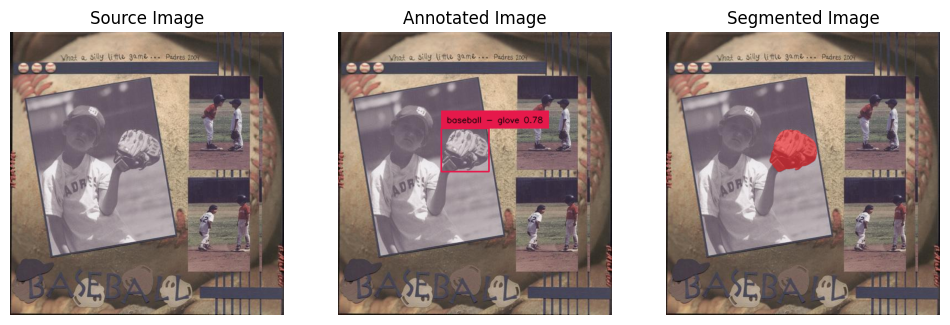

In [19]:
segmentation_model.graph_results(df, results, col="image_path", value="/kaggle/input/caltech-256/256_ObjectCategories/005.baseball-glove/005_0090.jpg")